# RL Debugging Notebook

Systematic debugging of the Locked Room environment training.

In [2]:
# Setup - Run this first
import sys
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Import environment
from environments import LockedRoomEnv, get_config, apply_reward_wrapper

# Import RL libraries
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.vec_env import DummyVecEnv

print("Imports successful!")

/Users/luisfilipecatalao/Documents/FEUP/3. TASI/maze/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.13.5)
Hello from the pygame community. https://www.pygame.org/contribute.html
Imports successful!


In [3]:
# Helper class - Flatten observation wrapper
class FlattenObs(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        img_size = np.prod(env.observation_space['image'].shape)
        self.observation_space = spaces.Box(0, 255, (img_size + 11,), np.float32)
    
    def observation(self, obs):
        img = obs['image'].flatten().astype(np.float32)
        d = np.zeros(4, np.float32)
        d[obs['direction']] = 1
        c = np.zeros(7, np.float32)
        c[obs['carrying']] = 1
        return np.concatenate([img, d, c])

# Helper function - Create environment
def make_env(render=False):
    config = get_config('E1')
    env = LockedRoomEnv(
        size=config.size,
        observation_mode='full_map',
        render_mode='human' if render else None,
        max_steps=200,
        fixed_agent_pos=config.fixed_agent_pos,
        fixed_goal_pos=config.fixed_goal_pos,
        num_doors=0,
    )
    env = apply_reward_wrapper(env, 'simple')
    return env

print("Helpers defined!")

Helpers defined!


## Test 1: Random Agent Success Rate

How often does a random agent reach the goal? If very rare, PPO will never learn.

In [4]:
# Test random agent success rate
env = make_env(render=False)

successes = 0
total_episodes = 1000
steps_to_goal = []

for ep in range(total_episodes):
    obs, info = env.reset()
    for step in range(200):
        action = env.action_space.sample()
        obs, reward, term, trunc, info = env.step(action)
        if term:
            successes += 1
            steps_to_goal.append(step + 1)
            break

env.close()

print(f"Random agent success rate: {successes}/{total_episodes} ({100*successes/total_episodes:.2f}%)")
if steps_to_goal:
    print(f"Average steps to goal (when successful): {np.mean(steps_to_goal):.1f}")
else:
    print("No successes - random exploration never reaches goal!")

Random agent success rate: 6/1000 (0.60%)
Average steps to goal (when successful): 150.2


## Test 2: Reward Distribution Analysis

What rewards does the agent typically see during random exploration?

Reward statistics:
  Mean: -0.018
  Std:  0.791
  Min:  -0.600
  Max:  100.000

Mean reward by action:
  PICKUP: -0.100 (n=4063)
  LEFT: 0.006 (n=3910)
  RIGHT: 0.006 (n=4037)
  FORWARD: 0.102 (n=3997)
  TOGGLE: -0.100 (n=3991)


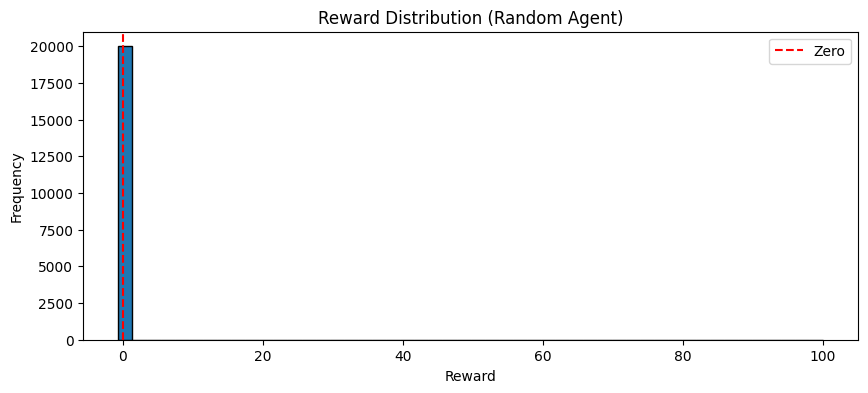

In [5]:
# Analyze reward distribution during random exploration
env = make_env(render=False)

all_rewards = []
reward_by_action = defaultdict(list)
action_names = ['LEFT', 'RIGHT', 'FORWARD', 'PICKUP', 'TOGGLE']

for ep in range(100):
    obs, info = env.reset()
    for step in range(200):
        action = env.action_space.sample()
        obs, reward, term, trunc, info = env.step(action)
        all_rewards.append(reward)
        reward_by_action[action].append(reward)
        if term or trunc:
            break

env.close()

print("Reward statistics:")
print(f"  Mean: {np.mean(all_rewards):.3f}")
print(f"  Std:  {np.std(all_rewards):.3f}")
print(f"  Min:  {np.min(all_rewards):.3f}")
print(f"  Max:  {np.max(all_rewards):.3f}")

print("\nMean reward by action:")
for action, rewards in reward_by_action.items():
    print(f"  {action_names[action]}: {np.mean(rewards):.3f} (n={len(rewards)})")

# Plot histogram
plt.figure(figsize=(10, 4))
plt.hist(all_rewards, bins=50, edgecolor='black')
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution (Random Agent)')
plt.axvline(x=0, color='r', linestyle='--', label='Zero')
plt.legend()
plt.show()

## Test 3: Position Coverage

What positions does random exploration visit? Does it ever reach the goal area?

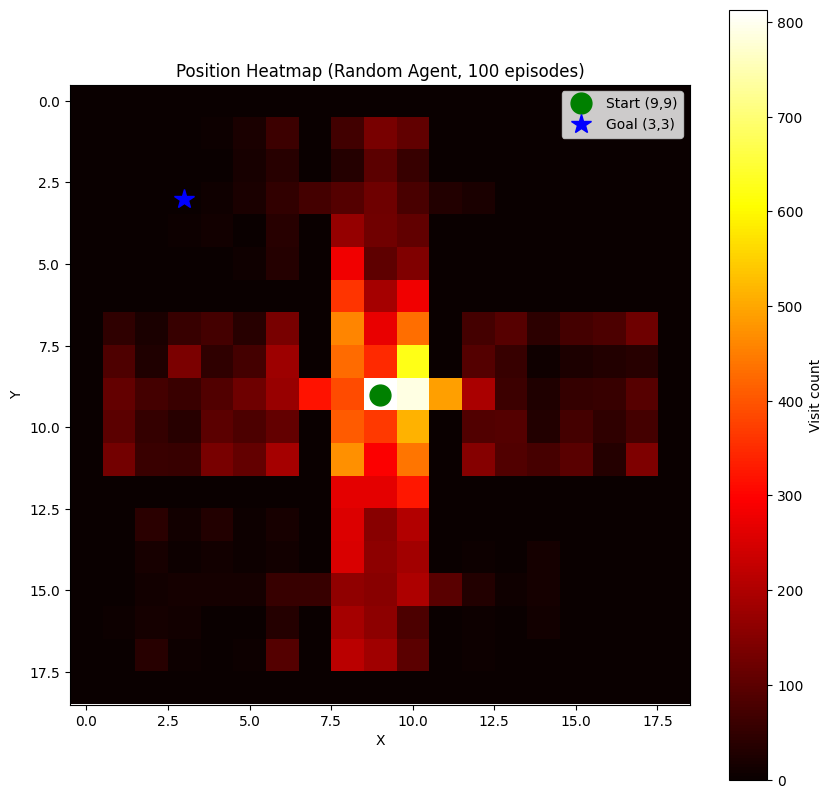


Goal room visits: 323/19952 (1.62%)


In [6]:
# Analyze position coverage
env = make_env(render=False)

position_counts = defaultdict(int)

for ep in range(100):
    obs, info = env.reset()
    for step in range(200):
        action = env.action_space.sample()
        obs, reward, term, trunc, info = env.step(action)
        pos = tuple(info['agent_pos'])
        position_counts[pos] += 1
        if term or trunc:
            break

env.close()

# Create heatmap
heatmap = np.zeros((19, 19))
for (y, x), count in position_counts.items():
    heatmap[y, x] = count

plt.figure(figsize=(10, 10))
plt.imshow(heatmap, cmap='hot', interpolation='nearest')
plt.colorbar(label='Visit count')
plt.title('Position Heatmap (Random Agent, 100 episodes)')

# Mark start and goal
plt.plot(9, 9, 'go', markersize=15, label='Start (9,9)')
plt.plot(3, 3, 'b*', markersize=15, label='Goal (3,3)')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# Check if goal area is ever visited
goal_room_visits = sum(count for (y, x), count in position_counts.items() if x < 7 and y < 6)
total_visits = sum(position_counts.values())
print(f"\nGoal room visits: {goal_room_visits}/{total_visits} ({100*goal_room_visits/total_visits:.2f}%)")

## Test 4: Action Sequence Analysis

What action sequences lead to the goal?

In [7]:
# Find successful action sequences
env = make_env(render=False)

successful_sequences = []

for ep in range(10000):  # More episodes to find successes
    obs, info = env.reset()
    actions = []
    for step in range(200):
        action = env.action_space.sample()
        actions.append(action)
        obs, reward, term, trunc, info = env.step(action)
        if term:
            successful_sequences.append(actions.copy())
            break

env.close()

print(f"Found {len(successful_sequences)} successful sequences out of 10000 episodes")

if successful_sequences:
    # Analyze shortest successful sequence
    shortest = min(successful_sequences, key=len)
    action_names = ['L', 'R', 'F', 'P', 'T']
    print(f"\nShortest successful sequence ({len(shortest)} steps):")
    print(''.join(action_names[a] for a in shortest[:50]), '...' if len(shortest) > 50 else '')
    
    # Length distribution
    lengths = [len(s) for s in successful_sequences]
    print(f"\nSuccessful sequence lengths:")
    print(f"  Min: {min(lengths)}")
    print(f"  Max: {max(lengths)}")
    print(f"  Mean: {np.mean(lengths):.1f}")

Found 86 successful sequences out of 10000 episodes

Shortest successful sequence (59 steps):
TTLFFPPRTRRTPRRRRPTRPFPLLLLLPLPRLPTTLLLFRTFLRPFPFL ...

Successful sequence lengths:
  Min: 59
  Max: 198
  Mean: 150.3


## Test 5: Manual Optimal Path Reward

What reward does the optimal path get?

In [8]:
# Execute optimal path manually
env = make_env(render=False)
obs, info = env.reset()

# Optimal: Turn left (face up), go forward 6, turn left (face left), go forward 6
optimal_actions = [
    0,  # Turn left (now facing up)
    2, 2, 2, 2, 2, 2,  # Forward 6 times (y: 9->3)
    0,  # Turn left (now facing left)
    2, 2, 2, 2, 2, 2,  # Forward 6 times (x: 9->3)
]

action_names = ['LEFT', 'RIGHT', 'FORWARD', 'PICKUP', 'TOGGLE']
total_reward = 0

print("Executing optimal path:")
print(f"Start: {info['agent_pos']}, Goal: {info['goal_pos']}")
print()

for i, action in enumerate(optimal_actions):
    old_pos = info['agent_pos'].copy()
    obs, reward, term, trunc, info = env.step(action)
    total_reward += reward
    print(f"Step {i+1}: {action_names[action]:8} | {old_pos} -> {info['agent_pos']} | reward: {reward:+.3f} | total: {total_reward:+.3f}")
    
    if term:
        print(f"\n*** GOAL REACHED! Total reward: {total_reward:.3f} ***")
        break

env.close()

Executing optimal path:
Start: [9, 9], Goal: (3, 3)

Step 1: LEFT     | [9, 9] -> [9, 9] | reward: +0.400 | total: +0.400
Step 2: FORWARD  | [9, 9] -> [8, 9] | reward: +0.900 | total: +1.300
Step 3: FORWARD  | [8, 9] -> [7, 9] | reward: +0.900 | total: +2.200
Step 4: FORWARD  | [7, 9] -> [6, 9] | reward: +0.900 | total: +3.100
Step 5: FORWARD  | [6, 9] -> [5, 9] | reward: +0.900 | total: +4.000
Step 6: FORWARD  | [5, 9] -> [4, 9] | reward: +0.900 | total: +4.900
Step 7: FORWARD  | [4, 9] -> [3, 9] | reward: +0.900 | total: +5.800
Step 8: LEFT     | [3, 9] -> [3, 9] | reward: +0.400 | total: +6.200
Step 9: FORWARD  | [3, 9] -> [3, 8] | reward: +0.900 | total: +7.100
Step 10: FORWARD  | [3, 8] -> [3, 7] | reward: +0.900 | total: +8.000
Step 11: FORWARD  | [3, 7] -> [3, 6] | reward: +10.900 | total: +18.900
Step 12: FORWARD  | [3, 6] -> [3, 5] | reward: +0.900 | total: +19.800
Step 13: FORWARD  | [3, 5] -> [3, 4] | reward: +0.900 | total: +20.700
Step 14: FORWARD  | [3, 4] -> [3, 3] | rew

## Test 6: Model Behavior at Different Positions

Load a trained model and see what actions it takes at different positions.

In [9]:
# Load model and test behavior at different positions
# Change this path to your trained model
MODEL_PATH = 'test_high_entropy'  # or 'results/models/E1_simple_PPO_full_map_XXXXX/E1_simple_PPO_full_map_final'

try:
    model = PPO.load(MODEL_PATH)
    print(f"Loaded model from {MODEL_PATH}")
except:
    print(f"Could not load model from {MODEL_PATH}")
    print("Train a model first or update the path")
    model = None

Loaded model from test_high_entropy


In [10]:
# Test model at different positions
if model is not None:
    env = make_env(render=False)
    env = FlattenObs(env)
    
    action_names = ['LEFT', 'RIGHT', 'FORWARD', 'PICKUP', 'TOGGLE']
    
    # Test positions along the optimal path and elsewhere
    test_cases = [
        ((9, 9), 0, "Start, facing right"),
        ((9, 9), 3, "Start, facing up"),
        ((5, 9), 3, "Halfway up corridor, facing up"),
        ((3, 9), 3, "Top of corridor, facing up"),
        ((3, 9), 2, "Top of corridor, facing left"),
        ((1, 9), 3, "Top wall, facing up"),
        ((1, 9), 2, "Top wall, facing left"),
        ((3, 5), 2, "In goal room, facing left"),
        ((3, 4), 2, "Near goal, facing left"),
    ]
    
    print("Model behavior at different positions:")
    print("=" * 60)
    
    for (y, x), direction, description in test_cases:
        # Reset and set position
        obs, info = env.reset()
        env.env.env.agent_pos = [y, x]
        env.env.env.agent_dir = direction
        
        # Get observation at this position
        obs = env.observation(env.env.env._get_obs())
        
        # Predict action
        action, _ = model.predict(obs, deterministic=True)
        action = int(action)
        
        dir_names = ['right', 'down', 'left', 'up']
        print(f"Pos ({y},{x}) facing {dir_names[direction]:5} -> {action_names[action]:8} | {description}")
    
    env.close()

Model behavior at different positions:
Pos (9,9) facing right -> LEFT     | Start, facing right
Pos (9,9) facing up    -> FORWARD  | Start, facing up
Pos (5,9) facing up    -> FORWARD  | Halfway up corridor, facing up
Pos (3,9) facing up    -> FORWARD  | Top of corridor, facing up
Pos (3,9) facing left  -> FORWARD  | Top of corridor, facing left
Pos (1,9) facing up    -> FORWARD  | Top wall, facing up
Pos (1,9) facing left  -> FORWARD  | Top wall, facing left
Pos (3,5) facing left  -> FORWARD  | In goal room, facing left
Pos (3,4) facing left  -> FORWARD  | Near goal, facing left


## Test 7: Train with Monitoring

Train a model and watch the reward curve.

In [11]:
# Custom callback to track rewards during training
from stable_baselines3.common.callbacks import BaseCallback

class RewardTracker(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_rewards = [0]
        
    def _on_step(self):
        # Track rewards
        self.current_rewards[0] += self.locals['rewards'][0]
        
        # Check if episode ended
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_rewards[0])
            self.current_rewards[0] = 0
            
            # Print progress every 100 episodes
            if len(self.episode_rewards) % 100 == 0:
                recent = self.episode_rewards[-100:]
                print(f"Episode {len(self.episode_rewards)}: mean={np.mean(recent):.2f}, max={np.max(recent):.2f}")
        
        return True

print("Callback defined!")

Callback defined!


In [12]:
# Train with monitoring
def make_vec_env():
    return FlattenObs(make_env(render=False))

env = DummyVecEnv([make_vec_env])
tracker = RewardTracker()

print("Training PPO for 100k steps...")
print("=" * 60)

model = PPO(
    'MlpPolicy', 
    env, 
    verbose=0,
    ent_coef=0.1,  # Try different values: 0.01, 0.1, 0.5
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
)

model.learn(total_timesteps=100000, callback=tracker)
model.save('notebook_trained_model')

print("\nTraining complete!")
env.close()

Training PPO for 100k steps...
Episode 100: mean=12.71, max=142.60
Episode 200: mean=22.96, max=122.40
Episode 300: mean=9.68, max=119.00
Episode 400: mean=21.81, max=127.20
Episode 500: mean=16.34, max=122.30

Training complete!


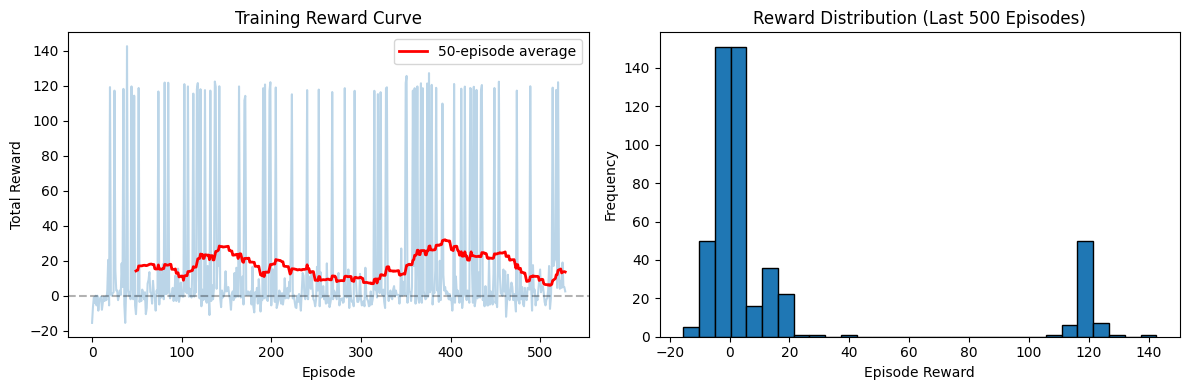


Final performance (last 100 episodes):
  Mean reward: 14.64
  Max reward: 122.30
  Success rate: 10/100


In [13]:
# Plot training curve
if tracker.episode_rewards:
    plt.figure(figsize=(12, 4))
    
    # Raw rewards
    plt.subplot(1, 2, 1)
    plt.plot(tracker.episode_rewards, alpha=0.3)
    
    # Smoothed rewards (rolling average)
    window = 50
    if len(tracker.episode_rewards) > window:
        smoothed = np.convolve(tracker.episode_rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(tracker.episode_rewards)), smoothed, 'r-', linewidth=2, label=f'{window}-episode average')
    
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Training Reward Curve')
    plt.legend()
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Histogram of final rewards
    plt.subplot(1, 2, 2)
    plt.hist(tracker.episode_rewards[-500:], bins=30, edgecolor='black')
    plt.xlabel('Episode Reward')
    plt.ylabel('Frequency')
    plt.title('Reward Distribution (Last 500 Episodes)')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nFinal performance (last 100 episodes):")
    final = tracker.episode_rewards[-100:]
    print(f"  Mean reward: {np.mean(final):.2f}")
    print(f"  Max reward: {np.max(final):.2f}")
    print(f"  Success rate: {sum(1 for r in final if r > 50)}/{len(final)}")

## Test 8: Evaluate Trained Model

In [14]:
# Evaluate the notebook-trained model
model = PPO.load('notebook_trained_model')

env = FlattenObs(make_env(render=False))

successes = 0
total_rewards = []

for ep in range(100):
    obs, info = env.reset()
    episode_reward = 0
    
    for step in range(200):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        episode_reward += reward
        
        if term:
            successes += 1
            break
    
    total_rewards.append(episode_reward)

env.close()

print(f"Success rate: {successes}/100 ({successes}%)")
print(f"Mean reward: {np.mean(total_rewards):.2f}")
print(f"Max reward: {np.max(total_rewards):.2f}")

Success rate: 0/100 (0%)
Mean reward: -14.50
Max reward: -14.50


## Test 9: Compare Different Hyperparameters

In [15]:
# Compare different entropy coefficients
def train_and_evaluate(ent_coef, steps=50000):
    env = DummyVecEnv([lambda: FlattenObs(make_env(render=False))])
    
    model = PPO(
        'MlpPolicy', 
        env, 
        verbose=0,
        ent_coef=ent_coef,
        learning_rate=0.0003,
    )
    model.learn(total_timesteps=steps)
    
    # Evaluate
    eval_env = FlattenObs(make_env(render=False))
    successes = 0
    
    for _ in range(100):
        obs, _ = eval_env.reset()
        for _ in range(200):
            action, _ = model.predict(obs, deterministic=True)
            obs, _, term, _, _ = eval_env.step(action)
            if term:
                successes += 1
                break
    
    env.close()
    eval_env.close()
    return successes

# Test different values
ent_coefs = [0.001, 0.01, 0.1, 0.5]
results = {}

for ent in ent_coefs:
    print(f"Training with ent_coef={ent}...")
    success = train_and_evaluate(ent)
    results[ent] = success
    print(f"  Success rate: {success}%")

print("\nResults:")
for ent, success in results.items():
    print(f"  ent_coef={ent}: {success}%")

Training with ent_coef=0.001...
  Success rate: 0%
Training with ent_coef=0.01...
  Success rate: 0%
Training with ent_coef=0.1...
  Success rate: 0%
Training with ent_coef=0.5...
  Success rate: 0%

Results:
  ent_coef=0.001: 0%
  ent_coef=0.01: 0%
  ent_coef=0.1: 0%
  ent_coef=0.5: 0%


## Test 10: Simplified Environment

Try with a smaller grid to see if the problem is grid size.

In [16]:
# Test with smaller observation (just agent position instead of full grid)
class SimpleObs(gym.ObservationWrapper):
    """Super simple observation: just position and direction"""
    def __init__(self, env):
        super().__init__(env)
        # [agent_y, agent_x, goal_y, goal_x, direction]
        self.observation_space = spaces.Box(0, 20, (5,), np.float32)
    
    def observation(self, obs):
        # Access base environment through wrapper chain
        base_env = self.env
        while hasattr(base_env, 'env'):
            base_env = base_env.env
        
        agent_pos = base_env.agent_pos
        goal_pos = base_env.goal_pos
        direction = base_env.agent_dir
        return np.array([agent_pos[0], agent_pos[1], goal_pos[0], goal_pos[1], direction], dtype=np.float32)

# Train with simple observation
def make_simple_env():
    config = get_config('E1')
    env = LockedRoomEnv(
        size=config.size,
        observation_mode='full_map',
        render_mode=None,
        max_steps=200,
        fixed_agent_pos=config.fixed_agent_pos,
        fixed_goal_pos=config.fixed_goal_pos,
        num_doors=0,
    )
    env = apply_reward_wrapper(env, 'simple')
    return SimpleObs(env)

print("Training with simplified observation (5 values instead of 1094)...")

env = DummyVecEnv([make_simple_env])
model = PPO('MlpPolicy', env, verbose=1, ent_coef=0.1)
model.learn(total_timesteps=50000)

# Evaluate
eval_env = make_simple_env()
successes = 0

for _ in range(100):
    obs, _ = eval_env.reset()
    for _ in range(200):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, term, _, _ = eval_env.step(action)
        if term:
            successes += 1
            break

print(f"\nSuccess rate with simple obs: {successes}%")
env.close()
eval_env.close()

Training with simplified observation (5 values instead of 1094)...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 9065 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 6117        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008281738 |
|    clip_fraction        | 0.0712      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.0475     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.26        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0132     |
|    value_loss           | 0.953 

In [17]:
# Test with more steps
env = make_env(render=False)
env.env.max_steps = 1000  # Increase max steps

successes = 0
for ep in range(1000):
    obs, info = env.reset()
    for step in range(1000):
        action = env.action_space.sample()
        obs, reward, term, trunc, info = env.step(action)
        if term:
            successes += 1
            break

print(f"Random success with 1000 steps: {successes}/1000 ({successes/10:.1f}%)")
env.close()

# Compare with 200 steps
env = make_env(render=False)
env.env.max_steps = 200

successes_200 = 0
for ep in range(1000):
    obs, info = env.reset()
    for step in range(200):
        action = env.action_space.sample()
        obs, reward, term, trunc, info = env.step(action)
        if term:
            successes_200 += 1
            break

print(f"Random success with 200 steps: {successes_200}/1000 ({successes_200/10:.1f}%)")
env.close()

Random success with 1000 steps: 91/1000 (9.1%)
Random success with 200 steps: 9/1000 (0.9%)


In [18]:
from environments import LockedRoomEnv, get_config, apply_reward_wrapper
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class SimpleObs(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(0, 20, (5,), np.float32)
    
    def observation(self, obs):
        base_env = self.env
        while hasattr(base_env, 'env'):
            base_env = base_env.env
        return np.array([
            base_env.agent_pos[0], 
            base_env.agent_pos[1], 
            base_env.goal_pos[0], 
            base_env.goal_pos[1], 
            base_env.agent_dir
        ], dtype=np.float32)

def make_env():
    config = get_config('E1')
    env = LockedRoomEnv(
        size=config.size,
        observation_mode='full_map',
        render_mode=None,
        max_steps=200,
        fixed_agent_pos=config.fixed_agent_pos,
        fixed_goal_pos=config.fixed_goal_pos,
        num_doors=0,
    )
    env = apply_reward_wrapper(env, 'simple')
    return SimpleObs(env)

# Train
env = DummyVecEnv([make_env])
model = PPO('MlpPolicy', env, verbose=1, ent_coef=0.1)
model.learn(total_timesteps=50000)
model.save('simple_obs_model')

# Evaluate
eval_env = make_env()
successes = 0
for _ in range(100):
    obs, _ = eval_env.reset()
    for _ in range(200):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, term, _, _ = eval_env.step(action)
        if term:
            successes += 1
            break

print(f"Success rate: {successes}%")

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 8143 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 5483         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0077877333 |
|    clip_fraction        | 0.064        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.6         |
|    explained_variance   | 0.0475       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.362        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0144      |
|    value_loss           | 1.16         |
------------------------------------------

In [19]:
# Quick test - does SimpleObs work at all?
from environments import LockedRoomEnv, get_config, apply_reward_wrapper
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class SimpleObs(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(0, 20, (5,), np.float32)
    
    def observation(self, obs):
        base_env = self.env
        while hasattr(base_env, 'env'):
            base_env = base_env.env
        return np.array([
            base_env.agent_pos[0], 
            base_env.agent_pos[1], 
            base_env.goal_pos[0], 
            base_env.goal_pos[1], 
            base_env.agent_dir
        ], dtype=np.float32)

# Test the observation
config = get_config('E1')
env = LockedRoomEnv(
    size=config.size,
    observation_mode='full_map',
    render_mode=None,
    max_steps=200,
    fixed_agent_pos=config.fixed_agent_pos,
    fixed_goal_pos=config.fixed_goal_pos,
    num_doors=0,
)
env = apply_reward_wrapper(env, 'simple')
env = SimpleObs(env)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Agent pos: {info['agent_pos']}, Goal: {info['goal_pos']}")
print(f"Expected: [9, 9, 3, 3, direction]")

# Check observation changes when we move
env.step(0)  # Turn left
obs2 = env.observation(env.env.env._get_obs())
print(f"After turn: {obs2}")

Observation: [9. 9. 3. 3. 0.]
Agent pos: [9, 9], Goal: (3, 3)
Expected: [9, 9, 3, 3, direction]
After turn: [9. 9. 3. 3. 3.]


In [20]:
# Run this in a NEW notebook cell
from environments import LockedRoomEnv, get_config, apply_reward_wrapper
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class SimpleObs(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(0, 20, (5,), np.float32)
    
    def observation(self, obs):
        base_env = self.env
        while hasattr(base_env, 'env'):
            base_env = base_env.env
        return np.array([
            base_env.agent_pos[0], 
            base_env.agent_pos[1], 
            base_env.goal_pos[0], 
            base_env.goal_pos[1], 
            base_env.agent_dir
        ], dtype=np.float32)

def make_env():
    config = get_config('E1')
    env = LockedRoomEnv(
        size=config.size,
        observation_mode='full_map',
        render_mode=None,
        max_steps=200,
        fixed_agent_pos=config.fixed_agent_pos,
        fixed_goal_pos=config.fixed_goal_pos,
        num_doors=0,
    )
    env = apply_reward_wrapper(env, 'simple')
    return SimpleObs(env)

# Test one episode manually first
print("Testing environment...")
test_env = make_env()
obs, info = test_env.reset()
print(f"Initial obs: {obs}")
print(f"Obs shape: {obs.shape}")
print(f"Obs space: {test_env.observation_space}")
test_env.close()

# Now train
print("\nTraining...")
env = DummyVecEnv([make_env])
model = PPO('MlpPolicy', env, verbose=1, ent_coef=0.1)
model.learn(total_timesteps=50000)

# Evaluate
print("\nEvaluating...")
eval_env = make_env()
successes = 0
for ep in range(100):
    obs, _ = eval_env.reset()
    for step in range(200):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, _ = eval_env.step(action)
        if term:
            successes += 1
            break

print(f"\nSuccess rate: {successes}/100 ({successes}%)")
eval_env.close()
env.close()

Testing environment...
Initial obs: [9. 9. 3. 3. 0.]
Obs shape: (5,)
Obs space: Box(0.0, 20.0, (5,), float32)

Training...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 8250 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 5800        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011757994 |
|    clip_fraction        | 0.128       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.0791      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.271       |
|    n_updates            | 10          |
|    policy_gradient

In [21]:
# Check what actions the model takes at each step
model = PPO.load('notebook_trained_model')  # or wherever you saved it

eval_env = make_env()
obs, info = eval_env.reset()

print("Watching one episode:")
print(f"Start: obs={obs}")

action_names = ['LEFT', 'RIGHT', 'FORWARD', 'PICKUP', 'TOGGLE']

for step in range(30):
    action, _ = model.predict(obs, deterministic=True)
    action = int(action)
    old_obs = obs.copy()
    obs, reward, term, trunc, info = eval_env.step(action)
    
    print(f"Step {step+1}: obs={old_obs} -> action={action_names[action]} -> new_obs={obs}, reward={reward:.2f}")
    
    if term:
        print("GOAL!")
        break

eval_env.close()

Watching one episode:
Start: obs=[9. 9. 3. 3. 0.]


ValueError: Error: Unexpected observation shape (5,) for Box environment, please use (1094,) or (n_env, 1094) for the observation shape.

In [ ]:
# Debug observation updates
env = make_env()
obs, info = env.reset()

print(f"After reset: obs={obs}, agent_pos={info['agent_pos']}")

# Turn left
obs, reward, term, trunc, info = env.step(0)
print(f"After LEFT: obs={obs}, agent_pos={info['agent_pos']}, dir should be 3")

# Move forward (should go up, y decreases)
obs, reward, term, trunc, info = env.step(2)
print(f"After FORWARD: obs={obs}, agent_pos={info['agent_pos']}, y should be 8")

# Move forward again
obs, reward, term, trunc, info = env.step(2)
print(f"After FORWARD: obs={obs}, agent_pos={info['agent_pos']}, y should be 7")

env.close()

After reset: obs=[9. 9. 3. 3. 0.], agent_pos=[9, 9]
After LEFT: obs=[9. 9. 3. 3. 3.], agent_pos=[9, 9], dir should be 3
After FORWARD: obs=[8. 9. 3. 3. 3.], agent_pos=[8, 9], y should be 8
After FORWARD: obs=[7. 9. 3. 3. 3.], agent_pos=[7, 9], y should be 7


In [22]:
# Complete training and evaluation with SimpleObs
from environments import LockedRoomEnv, get_config, apply_reward_wrapper
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class SimpleObs(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Box(0, 20, (5,), np.float32)
    
    def observation(self, obs):
        base_env = self.env
        while hasattr(base_env, 'env'):
            base_env = base_env.env
        return np.array([
            base_env.agent_pos[0], 
            base_env.agent_pos[1], 
            base_env.goal_pos[0], 
            base_env.goal_pos[1], 
            base_env.agent_dir
        ], dtype=np.float32)

def make_env():
    config = get_config('E1')
    env = LockedRoomEnv(
        size=config.size,
        observation_mode='full_map',
        render_mode=None,
        max_steps=200,
        fixed_agent_pos=config.fixed_agent_pos,
        fixed_goal_pos=config.fixed_goal_pos,
        num_doors=0,
    )
    env = apply_reward_wrapper(env, 'simple')
    return SimpleObs(env)

# Train
print("Training with SimpleObs (5 dimensions)...")
env = DummyVecEnv([make_env])
model = PPO('MlpPolicy', env, verbose=1, ent_coef=0.1)
model.learn(total_timesteps=50000)
model.save('simple_obs_model')
env.close()

# Evaluate using the SAME model we just trained (don't reload)
print("\nEvaluating...")
eval_env = make_env()

successes = 0
action_names = ['LEFT', 'RIGHT', 'FORWARD', 'PICKUP', 'TOGGLE']

for ep in range(100):
    obs, info = eval_env.reset()
    for step in range(200):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = eval_env.step(action)
        if term:
            successes += 1
            if ep < 3:  # Show first 3 successes
                print(f"  Episode {ep+1}: SUCCESS in {step+1} steps!")
            break
    
    if ep < 3 and not term:
        print(f"  Episode {ep+1}: Failed")

print(f"\nFinal Success rate: {successes}/100 ({successes}%)")
eval_env.close()

# Show what one successful episode looks like
print("\n--- Watching one episode ---")
watch_env = make_env()
obs, info = watch_env.reset()
print(f"Start: {obs}")

for step in range(30):
    action, _ = model.predict(obs, deterministic=True)
    action = int(action)
    obs, reward, term, trunc, info = watch_env.step(action)
    print(f"Step {step+1}: {action_names[action]:8} -> pos=[{obs[0]:.0f},{obs[1]:.0f}] dir={obs[4]:.0f} reward={reward:.2f}")
    if term:
        print("GOAL REACHED!")
        break

watch_env.close()

Training with SimpleObs (5 dimensions)...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 8535 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 5779        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010784866 |
|    clip_fraction        | 0.0954      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.0129     |
|    learning_rate        | 0.0003      |
|    loss                 | 0.407       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0152     |
|    value_loss           | 1.06        |
-----------------

In [ ]:
# Watch the trained model with rendering
import time

def make_render_env():
    config = get_config('E1')
    env = LockedRoomEnv(
        size=config.size,
        observation_mode='full_map',
        render_mode='human',  # This shows the window
        max_steps=200,
        fixed_agent_pos=config.fixed_agent_pos,
        fixed_goal_pos=config.fixed_goal_pos,
        num_doors=0,
    )
    env = apply_reward_wrapper(env, 'simple')
    return SimpleObs(env)

# Watch 3 episodes
watch_env = make_render_env()

for ep in range(3):
    obs, info = watch_env.reset()
    print(f"\nEpisode {ep+1}")
    
    for step in range(200):
        watch_env.render()
        time.sleep(0.15)  # Slow down so you can see
        
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = watch_env.step(action)
        
        if term:
            print(f"  Goal reached in {step+1} steps!")
            watch_env.render()
            time.sleep(1)  # Pause at goal
            break

watch_env.close()
print("\nDone!")


Episode 1
  Goal reached in 16 steps!

Episode 2
  Goal reached in 16 steps!

Episode 3
  Goal reached in 16 steps!

Done!


: 